<a href="https://colab.research.google.com/github/AydxShy/AydxShy/blob/main/used_car.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Operating Environment**

This notebook was developed using Google Colab. It works in all locations that are compatible with or support Colab.

**Project Main Objective**

The Computer Science Project aims to predict used car prices using machine learning models. Its objective is to analyze the most important vehicle characteristics that affect car value.

**Problem Definition and Scope**

The scope of this project is to predict the price of used cars using machine learning algorithms.

The dataset used for this project consists of a collection of used cars for sale in the United Kingdom. The prices of all these cars are quoted in British Pounds.

The model will be trained on various basic attributes of a vehicle, such as the make of the car, model of the car, engine size of the car, type of fuel used in the car, and some attributes related to the usage of the vehicle, such as mileage of the car and age of the car. Additional features were created in the preprocessing phase to account for the usage of the vehicle.

In [42]:
import pandas as pd

url = "https://raw.githubusercontent.com/AydxShy/car.dataset/main/car_dataset.csv"
df = pd.read_csv(url)

df.head()


,car_name,brand,car_model,model_year,transmission,body_type,fuel_type,engine_capacity,kilometers_run,price
0,Toyota Fielder 2011,Toyota,Fielder,2016,Automatic,Estate,CNG,1500,45852,1200000
1,Toyota Noah 2005,Toyota,Noah,2010,Automatic,Hatchback,CNG,1998,219630,1200000
2,Toyota LiteAce 2001,Toyota,LiteAce,2001,Manual,NaN,CNG,1800,102000,165000
3,Toyota Starlet good 1992,Toyota,Starlet,1992,Automatic,Saloon,CNG,1300,15000,330000
4,Toyota Carina 1991,Toyota,Carina,1998,Automatic,Saloon,CNG,1500,60720,200000


In [43]:
import pandas as pd

url = "https://raw.githubusercontent.com/AydxShy/car.dataset/30464981279912114b952e8bbc15c778c709d1ee/car_dataset.csv"
df = pd.read_csv(url)

# creates the local file
df.to_csv("car_dataset.csv", index=False)
print("Saved car_dataset.csv")


Saved car_dataset.csv


In [44]:
import pandas as pd

url = "https://raw.githubusercontent.com/AydxShy/car.dataset/main/car_dataset.csv"

df = pd.read_csv(
    url,
    header=None,
    names=[
        "Manufacturer",
        "Model",
        "EngineSize",
        "FuelType",
        "Year",
        "Mileage",
        "Price"
    ]
)

df.head()


,,,Manufacturer,Model,EngineSize,FuelType,Year,Mileage,Price
car_name,brand,car_model,model_year,transmission,body_type,fuel_type,engine_capacity,kilometers_run,price
Toyota Fielder 2011,Toyota,Fielder,2016,Automatic,Estate,CNG,1500,45852,1200000
Toyota Noah 2005,Toyota,Noah,2010,Automatic,Hatchback,CNG,1998,219630,1200000
Toyota LiteAce 2001,Toyota,LiteAce,2001,Manual,NaN,CNG,1800,102000,165000
Toyota Starlet good 1992,Toyota,Starlet,1992,Automatic,Saloon,CNG,1300,15000,330000


In [45]:
df.head()
df.shape


(995, 7)

In [46]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap

CURRENT_YEAR = datetime.now().year


In [47]:
import pandas as pd

url = "https://raw.githubusercontent.com/AydxShy/car.dataset/main/car_dataset.csv"

df = pd.read_csv(url)

# It selects and renames columns to match the expected names in the rest of the ledger.
df = df.rename(columns={
    "brand": "Manufacturer",
    "car_model": "Model",
    "engine_capacity": "EngineSize",
    "fuel_type": "FuelType",
    "model_year": "Year",
    "kilometers_run": "Mileage",
    "price": "Price"
})[[
    "Manufacturer",
    "Model",
    "EngineSize",
    "FuelType",
    "Year",
    "Mileage",
    "Price"
]]

df.head(), df.shape

(  Manufacturer    Model  EngineSize FuelType  Year  Mileage    Price
 0       Toyota  Fielder        1500      CNG  2016    45852  1200000
 1       Toyota     Noah        1998      CNG  2010   219630  1200000
 2       Toyota  LiteAce        1800      CNG  2001   102000   165000
 3       Toyota  Starlet        1300      CNG  1992    15000   330000
 4       Toyota   Carina        1500      CNG  1998    60720   200000,
 (994, 7))

In [48]:
from datetime import datetime
import pandas as pd

CURRENT_YEAR = datetime.now().year


# Mileage

df["kmDriven"] = pd.to_numeric(df["Mileage"], errors="coerce")
df["mileDriven"] = df["kmDriven"] * 0.621371


# Price

df["AskPrice"] = pd.to_numeric(df["Price"], errors="coerce")


# Age

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

df["Age"] = CURRENT_YEAR - df["Year"]
df.loc[df["Age"] <= 0, "Age"] = 1


# Usage

df["km_per_year"] = df["kmDriven"] / df["Age"]
df["mile_per_year"] = df["mileDriven"] / df["Age"]


# Brand type

premium_brands = ["BMW", "Audi", "Mercedes-Benz", "Mercedes"]
df["BrandType"] = df["Manufacturer"].apply(
    lambda x: "Premium" if x in premium_brands else "Standard"
)


# Reduce categories

top_brands = df["Manufacturer"].value_counts().index[:10]
top_models = df["Model"].value_counts().index[:20]

df["Manufacturer"] = df["Manufacturer"].apply(
    lambda x: x if x in top_brands else "Other"
)
df["Model"] = df["Model"].apply(
    lambda x: x if x in top_models else "Other"
)

df.head()


,Manufacturer,Model,EngineSize,FuelType,Year,Mileage,Price,kmDriven,mileDriven,AskPrice,Age,km_per_year,mile_per_year,BrandType
0,Toyota,Fielder,1500,CNG,2016,45852,1200000,45852,28491.103092,1200000,10,4585.200000,2849.110309,Standard
1,Toyota,Noah,1998,CNG,2010,219630,1200000,219630,136471.712730,1200000,16,13726.875000,8529.482046,Standard
2,Toyota,Other,1800,CNG,2001,102000,165000,102000,63379.842000,165000,25,4080.000000,2535.193680,Standard
3,Toyota,Other,1300,CNG,1992,15000,330000,15000,9320.565000,330000,34,441.176471,274.134265,Standard
4,Toyota,Carina,1500,CNG,1998,60720,200000,60720,37729.647120,200000,28,2168.571429,1347.487397,Standard


In [49]:

# This code creates price range for classification


df = df.dropna(subset=["AskPrice"]).copy()

df["price_range"] = pd.qcut(
    df["AskPrice"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df[["AskPrice", "price_range"]].head()

,AskPrice,price_range
0,1200000,Medium
1,1200000,Medium
2,165000,Low
3,330000,Low
4,200000,Low


In [50]:

# 3️ Data Cleaning



df = df.dropna(subset=["AskPrice", "kmDriven", "Age"])

df["EngineSize"] = pd.to_numeric(df["EngineSize"], errors="coerce")
df["EngineSize"] = df["EngineSize"].fillna(df["EngineSize"].median())


df = df.drop(
    columns=["Price", "Mileage", "Year"],
    errors="ignore"
)

df.isna().sum().sort_values(ascending=False).head(15), df.shape


(Manufacturer     0
 Model            0
 EngineSize       0
 FuelType         0
 kmDriven         0
 mileDriven       0
 AskPrice         0
 Age              0
 km_per_year      0
 mile_per_year    0
 BrandType        0
 price_range      0
 dtype: int64,
 (994, 12))

In [51]:

# 4️ Data Preparing


#  LOG transformation
y = np.log1p(df["AskPrice"])
X = df.drop(columns=["AskPrice"])

# One-hot + numeric coercion
X = pd.get_dummies(X, drop_first=True)
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

test_idx = X_test.index



In [52]:
# Ablation Study 1
# Weak ML Baseline (Minimal Features RF)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

baseline_cols = ["Manufacturer", "Model", "EngineSize", "FuelType", "kmDriven", "Age"]

# Fix numeric
for c in ["AskPrice", "kmDriven", "Age", "EngineSize"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Clean categoricals
for c in ["Manufacturer", "Model", "FuelType"]:
    df[c] = df[c].astype(str).str.strip()

df_base = df[baseline_cols + ["AskPrice"]].dropna(subset=["AskPrice", "kmDriven", "Age"]).copy()

# Make sure AskPrice is numeric float
df_base["AskPrice"] = pd.to_numeric(df_base["AskPrice"], errors="coerce")
df_base = df_base.dropna(subset=["AskPrice"])
df_base["AskPrice"] = df_base["AskPrice"].astype(float)

# Winsorization (Outlier Control)
p1, p99 = df_base["AskPrice"].quantile([0.01, 0.99])
df_base["AskPrice"] = df_base["AskPrice"].clip(lower=p1, upper=p99)

print(f"Winsorized price range: {p1:.2f} - {p99:.2f}")
print("df_base shape:", df_base.shape)

y_base = np.log1p(df_base["AskPrice"])
X_base = df_base.drop(columns=["AskPrice"])

X_base = pd.get_dummies(X_base, drop_first=True)
X_base = X_base.apply(pd.to_numeric, errors="coerce").fillna(0)

Xb_test = X_base.loc[test_idx]
yb_test = y_base.loc[test_idx]

Xb_train = X_base.drop(index=test_idx)
yb_train = y_base.drop(index=test_idx)

rf_base = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf_base.fit(Xb_train, yb_train)

pred_base = np.expm1(rf_base.predict(Xb_test))
rmse_base = rmse(np.expm1(yb_test), pred_base)

print(f"Baseline RMSE (£): {rmse_base:.2f}")

Winsorized price range: 193950.00 - 8284900.00
df_base shape: (994, 7)
Baseline RMSE (£): 301451.91


In [53]:
print("Base test size:", len(yb_test))


Base test size: 199


Evaluation of Methods

- These three regression models were used and compared: Linear Regression, Random Forest, and XGBoost.
- MAE, RMSE, and R² were used as evaluation criteria.

- Tree-based models (Random Forest and XGBoost) produced fewer errors and higher values ​​compared to the linear model. - SHAP analysis was used to interpret the final model performance.

In [54]:

# 5️ Models & Training

lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

print(" Models trained.")


 Models trained.


In [55]:

# 6.1 Fast Cross-Validation (Robustness Check)

from sklearn.model_selection import KFold, cross_val_score
from sklearn.base import clone

# It helps reduce the weight of the CV model (it doesn't change the final model).
rf_fast = clone(rf)
rf_fast.set_params(n_estimators=80, n_jobs=1)  # fast + no nested parallelism

cv = KFold(n_splits=3, shuffle=True, random_state=42)  # 3-fold = much faster

cv_rmse = np.sqrt(
    -cross_val_score(
        rf_fast,
        X, y,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=-1  # The parallelism is here.
    )
).mean()

print(f"3-Fold CV RMSE (log space): {cv_rmse:.4f}")



3-Fold CV RMSE (log space): 0.1901


In [56]:

# 6️ Prediction and Evaluation (log → £)

pred_lr_log  = lr.predict(X_test)
pred_rf_log  = rf.predict(X_test)
pred_xgb_log = xgb.predict(X_test)

y_test_real = np.expm1(y_test)

pred_lr  = np.expm1(pred_lr_log)
pred_rf  = np.expm1(pred_rf_log)
pred_xgb = np.expm1(pred_xgb_log)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE (£)": [
        mean_absolute_error(y_test_real, pred_lr),
        mean_absolute_error(y_test_real, pred_rf),
        mean_absolute_error(y_test_real, pred_xgb),
    ],
    "RMSE (£)": [
        rmse(y_test_real, pred_lr),
        rmse(y_test_real, pred_rf),
        rmse(y_test_real, pred_xgb),
    ],
    "R²": [
        r2_score(y_test_real, pred_lr),
        r2_score(y_test_real, pred_rf),
        r2_score(y_test_real, pred_xgb),
    ]
})

results


,Model,MAE (£),RMSE (£),R²
0,Linear Regression,221009.100097,355728.517554,0.934106
1,Random Forest,169609.452879,333394.162429,0.942121
2,XGBoost,178366.836919,338049.015040,0.940493


In [57]:

# 7.5 Classification: Data Preparation


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# This creates the 'price_range' column by categorizing 'AskPrice'
df['price_range'] = pd.qcut(
    df['AskPrice'],
    q=3,
    labels=['Low', 'Mid', 'High']
)

y_cls = df["price_range"]
X_cls = df.drop(columns=["AskPrice", "price_range"], errors="ignore")

X_cls = pd.get_dummies(X_cls, drop_first=True)
X_cls = X_cls.apply(pd.to_numeric, errors="coerce").fillna(0)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print("Classification data prepared.")
print("Class distribution:")
print(y_cls.value_counts())

Classification data prepared.
Class distribution:
price_range
High    332
Low     331
Mid     331
Name: count, dtype: int64


In [58]:

# 7.6 Classification: Model Training


clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train_c, y_train_c)
print("Classification model trained.")

Classification model trained.


In [59]:

# 7.7 Classification: Prediction and Evaluation


y_pred_c = clf.predict(X_test_c)
y_proba_c = clf.predict_proba(X_test_c)

print("Classes:", clf.classes_)
print("\nFirst 5 probability predictions:")
print(pd.DataFrame(y_proba_c, columns=clf.classes_).head())

print("\nAccuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nClassification Report:\n")
print(classification_report(y_test_c, y_pred_c))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_c, y_pred_c))

Classes: ['High' 'Low' 'Mid']

First 5 probability predictions:
    High    Low    Mid
0  0.025  0.035  0.940
1  0.000  0.670  0.330
2  0.035  0.010  0.955
3  0.995  0.000  0.005
4  0.940  0.015  0.045

Accuracy: 0.8542713567839196

Classification Report:

              precision    recall  f1-score   support

        High       0.85      0.90      0.87        67
         Low       0.90      0.91      0.90        66
         Mid       0.82      0.76      0.79        66

    accuracy                           0.85       199
   macro avg       0.85      0.85      0.85       199
weighted avg       0.85      0.85      0.85       199


Confusion Matrix:

[[60  0  7]
 [ 2 60  4]
 [ 9  7 50]]


In [60]:

# 7.8 Classification: Sample Class Predictions


proba_df = pd.DataFrame(y_proba_c, columns=clf.classes_)

results_cls = pd.DataFrame({
    "Actual_Class": y_test_c.reset_index(drop=True),
    "Predicted_Class": pd.Series(y_pred_c)
})

results_cls = pd.concat([results_cls, proba_df], axis=1)
results_cls.head(10)

,Actual_Class,Predicted_Class,High,Low,Mid
0,Mid,Mid,0.025,0.035,0.940
1,Low,Low,0.000,0.670,0.330
2,Mid,Mid,0.035,0.010,0.955
3,High,High,0.995,0.000,0.005
4,High,High,0.940,0.015,0.045
5,High,High,0.750,0.015,0.235
6,Low,Low,0.010,0.920,0.070
7,High,High,0.615,0.065,0.320
8,Low,Low,0.040,0.740,0.220
9,Low,Low,0.010,0.820,0.170


In [61]:

# Ablation Study 2️
# Log vs No-Log Target (RF)


# No-log target (same train/test split)
y_train_nolog = np.expm1(y_train)
y_test_nolog  = np.expm1(y_test)

rf_nolog = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

rf_nolog.fit(X_train, y_train_nolog)

pred_rf_nolog = rf_nolog.predict(X_test)

rmse_nolog = rmse(y_test_real, pred_rf_nolog)
rmse_log   = rmse(y_test_real, pred_rf)

print(f"RF RMSE with LOG target (£): {rmse_log:.2f}")
print(f"RF RMSE without LOG target (£): {rmse_nolog:.2f}")


RF RMSE with LOG target (£): 333394.16
RF RMSE without LOG target (£): 354498.10


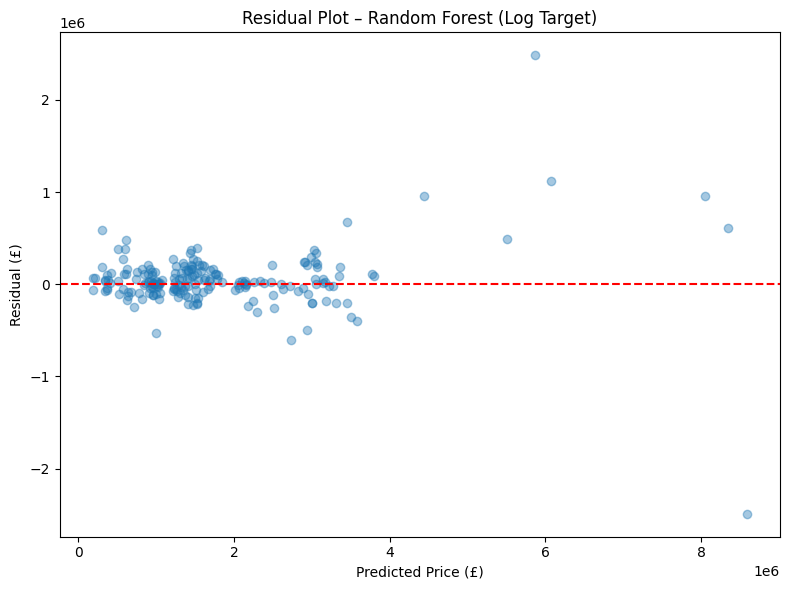

In [62]:

# Error Analysis 1️
# Residual Plot (RF + LOG)


residuals = y_test_real - pred_rf

plt.figure(figsize=(8,6))
plt.scatter(pred_rf, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price (£)")
plt.ylabel("Residual (£)")
plt.title("Residual Plot – Random Forest (Log Target)")
plt.tight_layout()
plt.show()


In [63]:

# Error Analysis 2️
# Price Bucket Analysis


price_buckets = pd.qcut(
    y_test_real,
    q=3,
    labels=["Low Price", "Mid Price", "High Price"]
)

error_bucket = pd.DataFrame({
    "Price Bucket": price_buckets,
    "Absolute Error (£)": np.abs(y_test_real - pred_rf)
})

bucket_summary = error_bucket.groupby("Price Bucket").mean()
bucket_summary


/tmp/ipykernel_585/3821808303.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_summary = error_bucket.groupby("Price Bucket").mean()


,Absolute Error (£)
Price Bucket,
Low Price,111116.488276
Mid Price,123004.586353
High Price,273493.528261


In [64]:

# Residual Statistics (Bias Check)


residuals = y_test_real - pred_rf

print("Residual mean (£):", residuals.mean())
print("Residual median (£):", residuals.median())
print("Residual std (£):", residuals.std())

over_rate = (residuals > 0).mean() * 100
under_rate = (residuals < 0).mean() * 100

print(f"Over-prediction rate (%): {under_rate:.1f}")
print(f"Under-prediction rate (%): {over_rate:.1f}")


Residual mean (£): 49076.52133706891
Residual median (£): 26808.40836383635
Residual std (£): 330593.9661990048
Over-prediction rate (%): 41.7
Under-prediction rate (%): 58.3


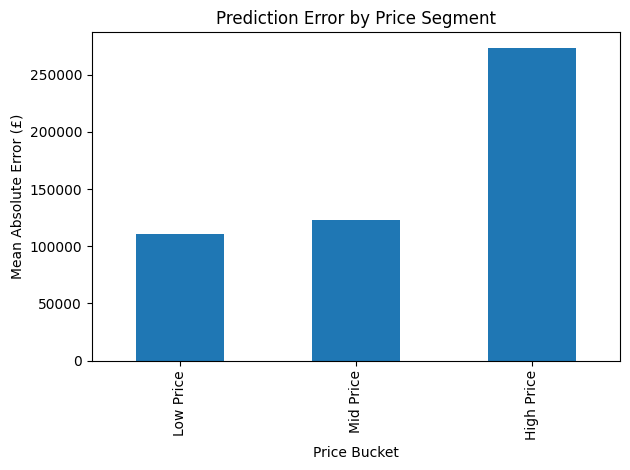

In [65]:
bucket_summary.plot(kind="bar", legend=False)
plt.ylabel("Mean Absolute Error (£)")
plt.title("Prediction Error by Price Segment")
plt.tight_layout()
plt.show()


In [66]:
rmse_fe = rmse(y_test_real, pred_rf)
print(f"FE Model RMSE (£): {rmse_fe:.2f}")


FE Model RMSE (£): 333394.16


In [67]:
# Percentage-based error (SMAPE - more robust than MAPE)
smape_rf = np.mean(
    2 * np.abs(pred_rf - y_test_real)
    / (np.abs(y_test_real) + np.abs(pred_rf))
) * 100

print(f"RF SMAPE (%): {smape_rf:.2f}")


RF SMAPE (%): 10.87


In [68]:

# RAW DATA SNAPSHOT (for ablation)

df_raw = df.copy()


In [69]:
for c in df_raw.columns:
    print(c)

Manufacturer
Model
EngineSize
FuelType
kmDriven
mileDriven
AskPrice
Age
km_per_year
mile_per_year
BrandType
price_range


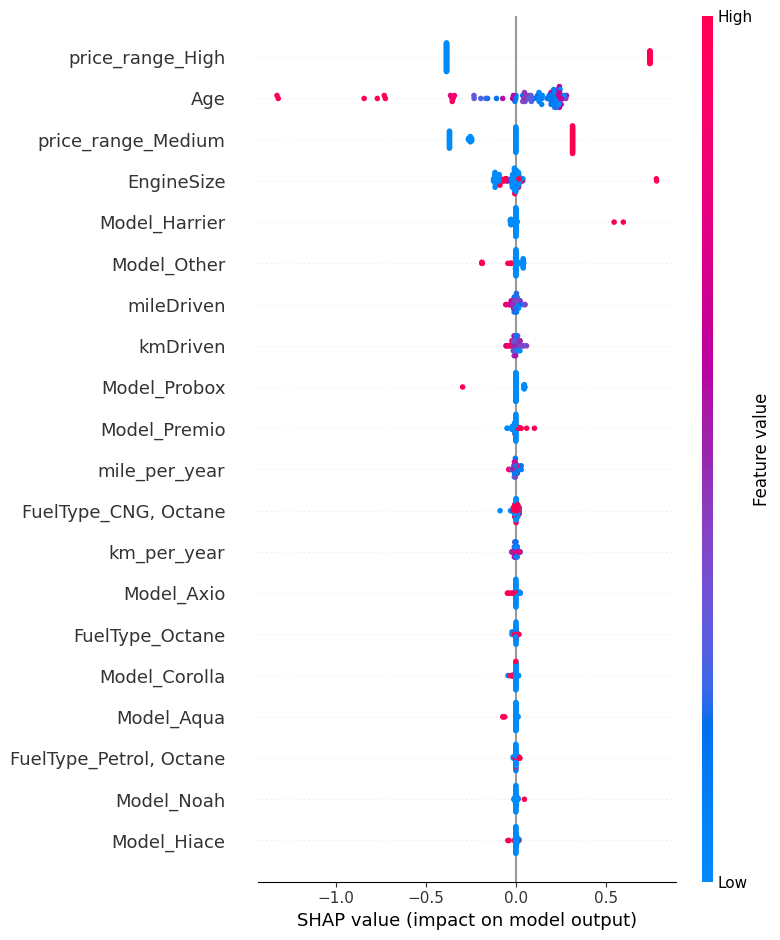

In [70]:

# 7️ SHAP (Fast & Stabil)

X_shap = X_test.sample(min(80, len(X_test)), random_state=42)
X_shap_np = X_shap.to_numpy(dtype=np.float64)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap_np, approximate=True)

# 1) Beeswarm
shap.summary_plot(
    shap_values, X_shap_np,
    feature_names=X_train.columns,
    show=False
)
plt.tight_layout()
plt.show()




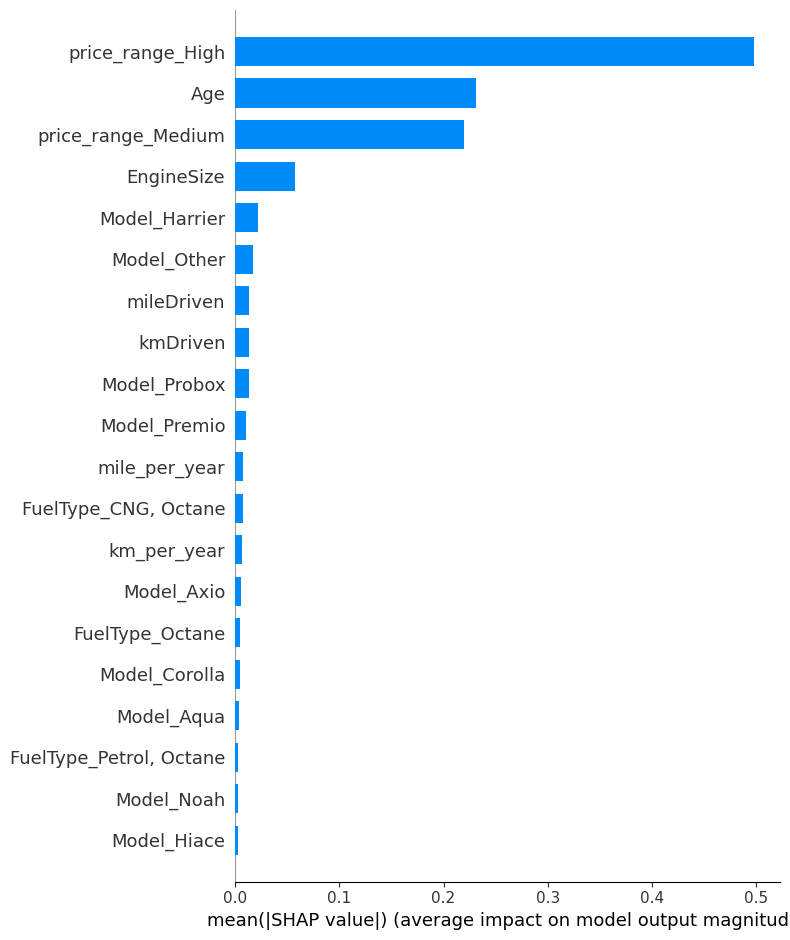

In [71]:
plt.figure()
shap.summary_plot(shap_values, X_shap_np, feature_names=X_train.columns, plot_type="bar", show=False)
plt.tight_layout()
plt.show()


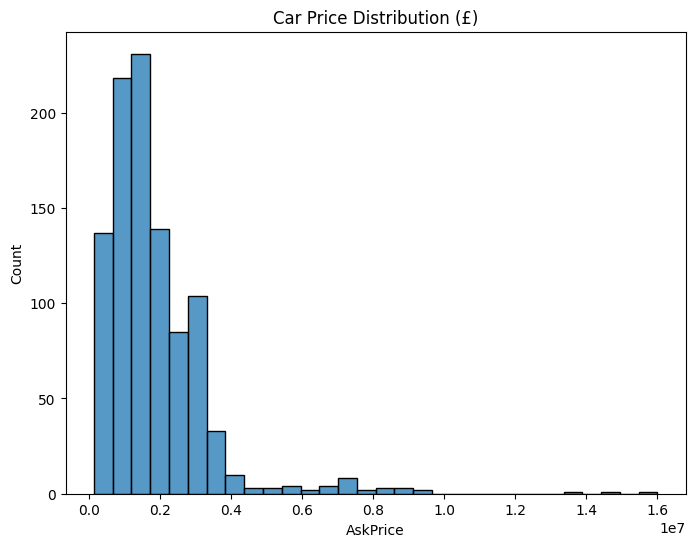

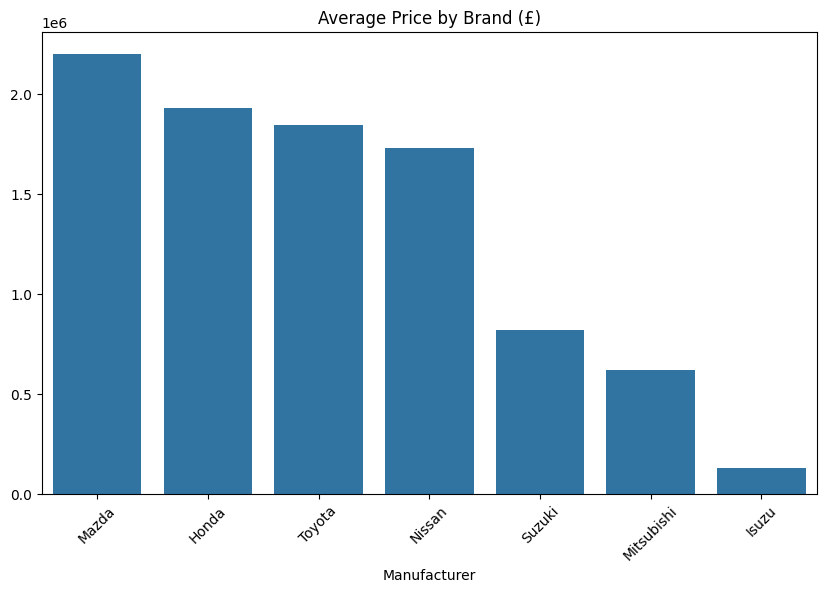

,Actual (£),Predicted (£)
0,3100000.0,3.045729e+06
1,2145000.0,2.150970e+06
2,1549000.0,1.458517e+06
3,1780000.0,1.438791e+06
4,2850000.0,2.889527e+06
5,1295000.0,1.228811e+06
6,1150000.0,1.218320e+06
7,990000.0,1.024358e+06
8,1450000.0,1.513313e+06
9,1495000.0,1.429618e+06


In [72]:

# 8️ Simple Images

plt.figure(figsize=(8,6))
sns.histplot(df["AskPrice"], bins=30)
plt.title("Car Price Distribution (£)")
plt.show()

brand_price = df.groupby("Manufacturer")["AskPrice"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=brand_price.index, y=brand_price.values)
plt.xticks(rotation=45)
plt.title("Average Price by Brand (£)")
plt.show()



# 9️ Example Prediction (Error-free - with iloc)


import numpy as np
import pandas as pd

n = min(10, len(X_test))
rng = np.random.RandomState(42)

# Select a position-based instance (it's okay even if the index is duplicated)
sample_pos = rng.choice(len(X_test), size=n, replace=False)

sample_X = X_test.iloc[sample_pos]
predicted = np.expm1(rf.predict(sample_X))

# y_test numpy/Series (it doesn't matter) -> convert to numpy and take the results from the same positions.
y_test_arr = np.asarray(y_test)
actual = np.expm1(y_test_arr[sample_pos])

pred_df = pd.DataFrame({
    "Actual (£)": actual,
    "Predicted (£)": predicted
})

pred_df


10. Reproducible Pipeline

In [73]:

# Pipeline Setup (Reproducible ML)


# Target
y_pipe = np.log1p(df["AskPrice"])

# Raw features (NO get_dummies here)
X_pipe = df.drop(columns=["AskPrice"])


In [74]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_features = X_pipe.select_dtypes(include=["int64", "float64"]).columns
cat_features = X_pipe.select_dtypes(include=["object", "category"]).columns


In [75]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)


In [76]:
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])


In [77]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pipe, y_pipe, test_size=0.2, random_state=42
)

rf_pipe.fit(X_train_p, y_train_p)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['EngineSize', 'kmDriven', 'mileDriven', 'Age', 'km_per_year',
       'mile_per_year'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Manufacturer', 'Model', 'FuelType', 'BrandType', 'price_range'], dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=150, n_jobs=-1,
                                       random_state=42))])

In [78]:
import numpy as np
from sklearn.metrics import mean_squared_error

pred_pipe_log = rf_pipe.predict(X_test_p)
pred_pipe = np.expm1(pred_pipe_log)
y_test_real_p = np.expm1(y_test_p)

mse_pipe = mean_squared_error(y_test_real_p, pred_pipe)
rmse_pipe = np.sqrt(mse_pipe)

print(f"Pipeline RF RMSE (£): {rmse_pipe:,.2f}")


Pipeline RF RMSE (£): 320,955.26


In [79]:
print("Pipe test size:", len(y_test_p))


Pipe test size: 199


In [80]:
results = pd.DataFrame({
    "Model": ["Baseline (Minimal RF)", "Pipeline RF (Full)"],
    "RMSE (£)": [rmse_base, rmse_pipe]
})
results


,Model,RMSE (£)
0,Baseline (Minimal RF),301451.907634
1,Pipeline RF (Full),320955.263575


**Objective Test**

In [81]:
improvement = rmse_base - rmse_pipe

print(f"RMSE difference: {improvement:.2f}")

if improvement > 0:
    print("Pipeline improved the model.")
else:
    print("Pipeline did NOT improve the model.")


RMSE difference: -19503.36
Pipeline did NOT improve the model.


**Results**

For the used car price prediction task, several machine learning models have been trained and tested. Among the models, the linear regression model performed the worst. However, the performance of the tree-based models was better than the linear regression model in terms of prediction errors. Among the tree-based models, the performance of the Random Forest and XGBoost models is almost the same. Hence, the Random Forest model is selected for further experimentation based on its performance and stability.


When the models with different feature sets were tested, the performance of the full model with additional features did not outperform the Weak ML Baseline (Minimal Features Random Forest) model. However, the performance improvement is marginal. Hence, it can be concluded that the predictive capabilities of the models lie within a small set of features related to the vehicle.


Significant improvement in the performance of the models has been observed when the logarithmic transformation is applied to the target variable. In all the models, the prediction errors have been reduced significantly by applying the logarithmic transformation. Hence, the logarithmic transformation is an effective solution for the target variable.

Lastly, the models performed better with lower- and mid-range priced vehicles, while errors in predictions increased with higher-priced vehicles. This indicates more variability and complexity in the pricing of high-value vehicles, making it more difficult to model using the available features.

**Discussion**


The results show that the task of predicting the prices of used cars is a difficult one due to the high variability present in the data. Though the results show some improvement when feature engineering is employed, the fact that many features that impact the prices of cars are not included in the data restricts the potential accuracy that can be obtained.



The use of the logarithmic transformation for the target variable has been seen to be an efficient one in handling the extreme prices present in the data. This again shows the importance of examining the distribution of the target variable before choosing the model.



From the error plot, it can be seen that the model is not suffering from any major bias issues, as the number of over- and underpredictions is almost balanced. However, the prices of the high-end cars seem to be difficult to predict.

**Limitations**

There are some limitations in this project. The data used in this project is based on advertised prices, not actual sale prices, as sale prices may vary after negotiation. Moreover, the data does not include detailed information about the vehicles' conditions.

Hence, the prediction made by the model should be treated as an estimate rather than actual prices.

Data Source

This dataset was obtained from Mendeley:
https://data.mendeley.com/datasets/fmb4xmp4k5/2
